<a href="https://colab.research.google.com/github/amnajamil381-png/AI-ML-Internship/blob/main/Task%202%3A%20Predicting%20Future%20Stock%20Prices/Predicting_Future_Stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing libraries

In [1]:
!pip install yfinance

Importing libraries

In [2]:
import yfinance as yf   #To import data from yahoo finance library
import pandas as pd     #To load dataset
import numpy as np      #To work with arrays
import matplotlib.pyplot as plt    #used for plotting

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Downloading stock data

In [3]:
data = yf.download("AAPL", period = "5y")   #the ticker of 5 years has to be used

/tmp/ipykernel_13686/1736650060.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period = "5y")   #the ticker of 5 years has to be used
[*********************100%***********************]  1 of 1 completed


Creating target

In [4]:
data['Target'] = data['Close'].shift(-1)  #the target will predict tomorrow's close using today's data

Removing missing row

In [5]:
data.dropna(inplace=True)

Selecting features

In [6]:
X = data[['Open','High','Low','Volume']]    #to make predictions
y = data['Target']                          #what we want to predict

Splitting data into train and test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False    #to keep the chronological order of the data
)

Training the model with training data

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predicting the data using test data

In [9]:
predictions = model.predict(X_test)

Evaluating metrics to see the wellness of trained model

In [10]:
mae = mean_absolute_error(y_test, predictions)          #average mistakes made by the model
rmse = np.sqrt(mean_squared_error(y_test, predictions)) #penalizes larger mistakes
r2 = r2_score(y_test, predictions)                      #variations in stock prices model can explain

Plotting the data tested and predicted by the model

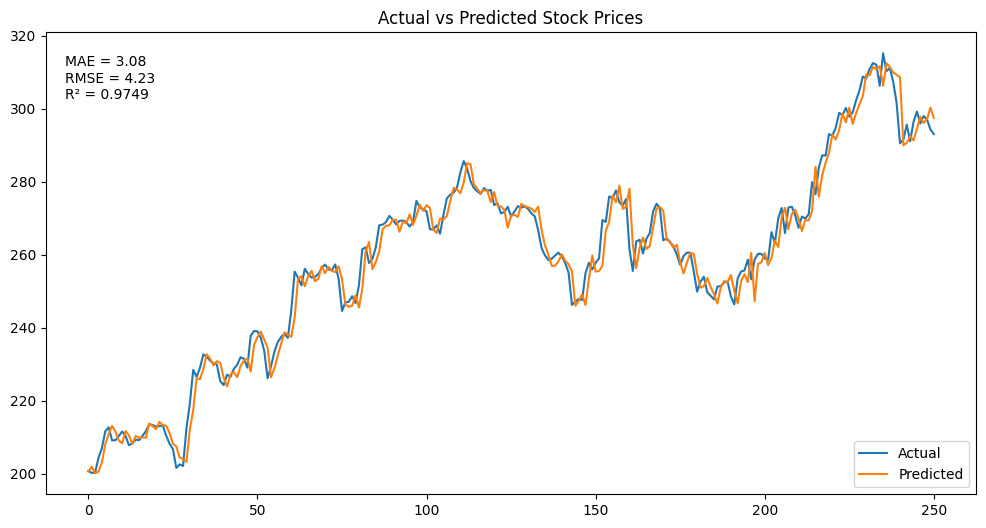

In [11]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')   #plot the training data outcomes
plt.plot(predictions, label='Predicted')  #plot the tested data outcomes

plt.title('Actual vs Predicted Stock Prices')

plt.text(
    0.02,
    0.95,
    f'MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.4f}', #display the evaluation metrics values
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.legend()
plt.show()

The closeness of actual and predicted lines shows that the model is well trained and reliable.

The interpretation of evaluation metrics are:

In [12]:
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

if r2 >= 0.8:
    print("Model Reliability: High")
elif r2 >= 0.6:
    print("Model Reliability: Moderate")
else:
    print("Model Reliability: Low")

MAE : 3.08
RMSE: 4.23
R²  : 0.9749
Model Reliability: High
